# Kunci Jawaban - Linear Regression

- **Dataset:** [QSAR Fish Toxicity](https://archive.ics.uci.edu/dataset/504/qsar+fish+toxicity)
- **Target:** `LC50`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, dan scatter plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Siapkan URL dataset UCI

Gunakan URL raw dataset QSAR Fish Toxicity dari UCI.

In [5]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00504/qsar_fish_toxicity.csv"

### Siapkan nama kolom

Siapkan nama kolom karena file raw UCI tidak memiliki header.

In [6]:
COLUMN_NAMES = ["CIC0", "SM1_Dz_Z", "GATS1i", "NdsCH", "NdssC", "MLOGP", "LC50"]

### Baca dataset raw UCI

Baca dataset raw UCI yang dipisahkan tanda titik koma menjadi DataFrame bernama `df`.

In [7]:
df = pd.read_csv(DATA_URL, sep=";", header=None, names=COLUMN_NAMES)

### Tentukan kolom target

Tentukan kolom `LC50` sebagai target prediksi.

In [8]:
TARGET_COL = "LC50"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [9]:
df.shape

(908, 7)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 908 baris dan 7 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [10]:
df.head()

,CIC0,SM1_Dz_Z,GATS1i,NdsCH,NdssC,MLOGP,LC50
0,3.260,0.829,1.676,0,1,1.453,3.770
1,2.189,0.580,0.863,0,0,1.348,3.115
2,2.125,0.638,0.831,0,0,1.348,3.531
3,3.027,0.331,1.472,1,0,1.807,3.510
4,2.094,0.827,0.860,0,0,1.886,5.390


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya. Semua kolom berisi angka.

> Kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `LC50`.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CIC0      908 non-null    float64
 1   SM1_Dz_Z  908 non-null    float64
 2   GATS1i    908 non-null    float64
 3   NdsCH     908 non-null    int64  
 4   NdssC     908 non-null    int64  
 5   MLOGP     908 non-null    float64
 6   LC50      908 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 49.8 KB


> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `float64` dan `int64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 908 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [12]:
df.isna().sum()

CIC0        0
SM1_Dz_Z    0
GATS1i      0
NdsCH       0
NdssC       0
MLOGP       0
LC50        0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [13]:
df.duplicated().sum()

np.int64(1)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 1.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk seluruh kolom numerik.

In [14]:
df.describe()

,CIC0,SM1_Dz_Z,GATS1i,NdsCH,NdssC,MLOGP,LC50
count,908.000,908.000,908.000,908.000,908.000,908.000,908.000
mean,2.898,0.628,1.294,0.229,0.486,2.109,4.064
std,0.756,0.428,0.394,0.605,0.861,1.433,1.456
min,0.667,0.000,0.396,0.000,0.000,-2.884,0.053
25%,2.347,0.223,0.951,0.000,0.000,1.209,3.152
50%,2.934,0.570,1.240,0.000,0.000,2.127,3.987
75%,3.407,0.893,1.562,0.000,1.000,3.105,4.907
max,5.926,2.171,2.920,4.000,6.000,6.515,9.612


> Berdasarkan statistik deskriptif, berapa rata-rata target `LC50`?

Jawaban: Rata-rata target `LC50` sekitar 4.064.

> Berdasarkan statistik deskriptif, berapa nilai minimum dan maksimum target?

Jawaban: Minimum target 0.053 dan maksimum target 9.612.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [15]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [16]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [17]:
df_clean.shape

(907, 7)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset menjadi 907 baris dan 7 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [18]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `LC50`.

In [19]:
df_clean[TARGET_COL].describe()

count   907.000
mean      4.065
std       1.456
min       0.053
25%       3.151
50%       3.991
75%       4.909
max       9.612
Name: LC50, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 4.066, minimum 0.053, dan maksimum 9.612.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `LC50`.

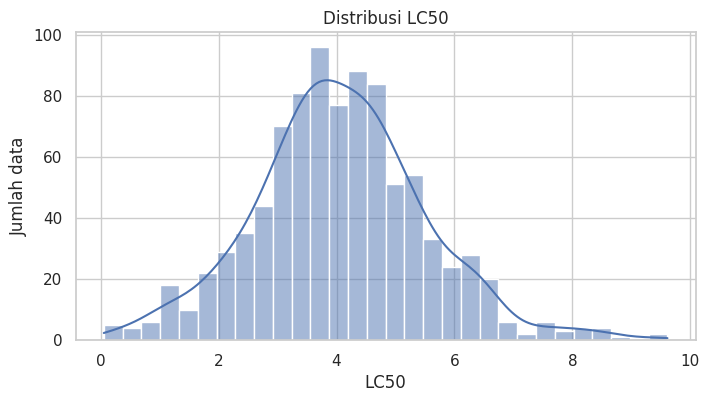

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi LC50")
plt.xlabel("LC50")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang sekitar 3.558 sampai 3.877.

> Apakah distribusi target terlihat sangat miring atau relatif menyebar di sekitar tengah?

Jawaban: Distribusi target relatif menyebar di sekitar tengah.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `LC50`.

In [21]:
numeric_corr = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

MLOGP       0.652
SM1_Dz_Z    0.411
CIC0        0.292
NdssC       0.172
NdsCH       0.172
GATS1i     -0.398
Name: LC50, dtype: float64

> Berdasarkan output korelasi, fitur apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `MLOGP` memiliki korelasi positif paling tinggi terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: Fitur `GATS1i` memiliki korelasi negatif terhadap target.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

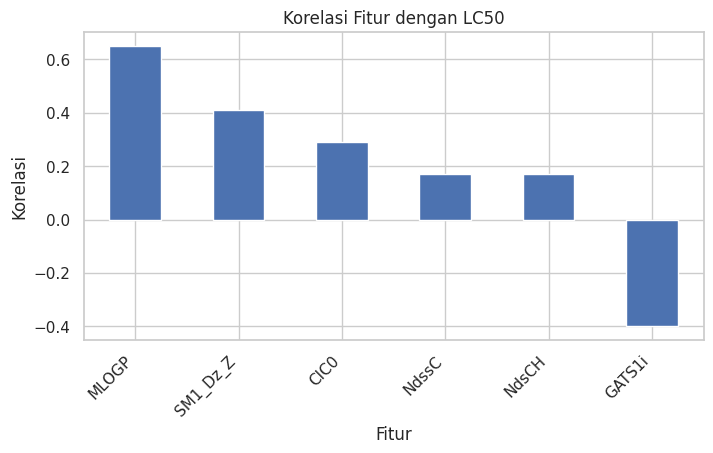

In [22]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur dengan LC50")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang paling positif hubungannya dengan target?

Jawaban: `MLOGP` paling positif hubungannya dengan target.

> Fitur mana yang memiliki arah korelasi negatif?

Jawaban: `GATS1i` memiliki arah korelasi negatif.

### Buat scatter plot MLOGP dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `MLOGP` dengan target.

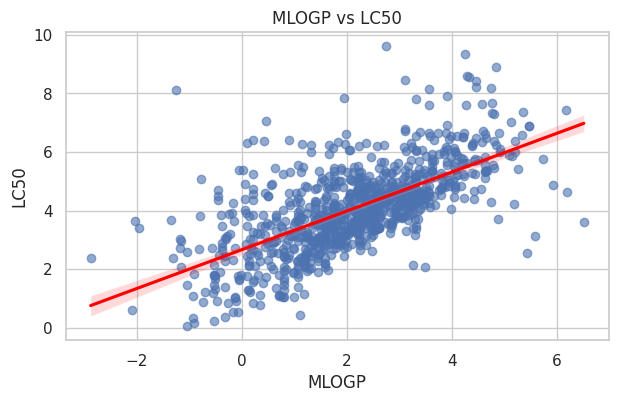

In [23]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="MLOGP", y=TARGET_COL, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("MLOGP vs LC50")
plt.xlabel("MLOGP")
plt.ylabel("LC50")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `MLOGP` dengan target?

Jawaban: Polanya cenderung positif; semakin tinggi `MLOGP`, nilai `LC50` cenderung lebih tinggi.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan positif.

### Buat scatter plot GATS1i dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `GATS1i` dengan target.

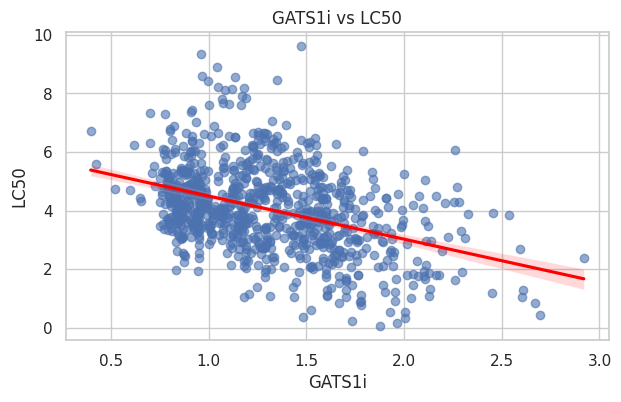

In [24]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="GATS1i", y=TARGET_COL, scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("GATS1i vs LC50")
plt.xlabel("GATS1i")
plt.ylabel("LC50")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `GATS1i` dengan target?

Jawaban: Polanya cenderung negatif; semakin tinggi `GATS1i`, nilai `LC50` cenderung lebih rendah.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan negatif.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan semua kolom selain target sebagai fitur awal.

In [25]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [26]:
y = df_clean[TARGET_COL]

### Gunakan fitur numerik

Gunakan fitur numerik yang sudah tersedia karena dataset ini tidak memiliki kolom kategori.

In [27]:
X = X_raw_model.copy()

### Tampilkan ukuran fitur

Tampilkan ukuran `X` yang akan digunakan untuk modeling.

In [28]:
X.shape

(907, 6)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki 907 baris dan 6 fitur.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [29]:
y.shape

(907,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 907 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [30]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [32]:
X_train.shape

(725, 6)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [33]:
X_test.shape

(182, 6)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 725 baris dan data test memiliki 182 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [34]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [35]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [36]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [37]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [38]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [39]:
model.intercept_

np.float64(4.088587586206897)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 4.089.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [40]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
1,SM1_Dz_Z,0.557
5,MLOGP,0.540
0,CIC0,0.302
3,NdsCH,0.216
4,NdssC,0.046
2,GATS1i,-0.307


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `SM1_Dz_Z` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `GATS1i` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [41]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [42]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [43]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,2.870,3.678
1,6.213,5.201
2,3.779,2.652
3,1.691,2.549
4,4.421,4.165


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris kelima terlihat paling dekat karena actual 4.421 dan predicted sekitar 4.165.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris ketiga terlihat paling jauh karena actual 3.779 dan predicted sekitar 2.652.

### Hitung MAE train

Hitung MAE pada data train.

In [44]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

0.6695271604991044

### Hitung MAE test

Hitung MAE pada data test.

In [45]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

0.7731275100889137

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 0.773.

### Hitung RMSE train

Hitung RMSE pada data train.

In [46]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(0.9198048110979758)

### Hitung RMSE test

Hitung RMSE pada data test.

In [47]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(1.0500449060355577)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 1.050.

### Hitung R2 train

Hitung R2 Score pada data train.

In [48]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.5877247787098272

### Hitung R2 test

Hitung R2 Score pada data test.

In [49]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.535551745350749

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.536.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [50]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,0.670,0.920,0.588
1,Test,0.773,1.050,0.536


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 15.47% lebih tinggi daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 14.16% lebih tinggi daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 8.88% lebih rendah daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

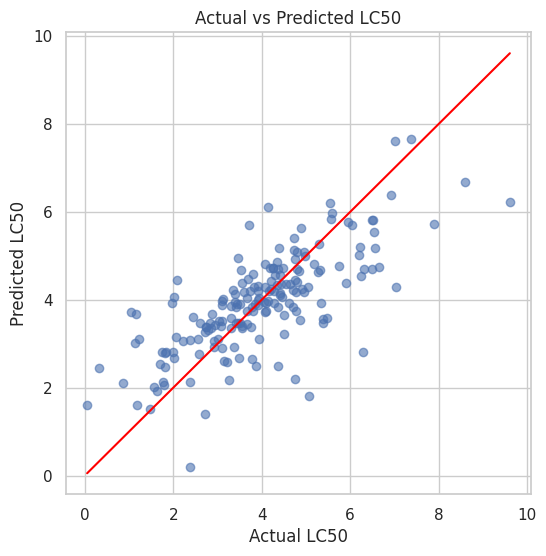

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted LC50")
plt.xlabel("Actual LC50")
plt.ylabel("Predicted LC50")
plt.show()

## 11 - Kesimpulan

Dataset QSAR Fish Toxicity digunakan untuk memprediksi `LC50` berdasarkan deskriptor kimia molekul. Dataset memiliki 908 baris dan 7 kolom sebelum cleaning. Data tidak memiliki missing value dan memiliki 1 baris duplikat penuh.

EDA menunjukkan bahwa target `LC50` relatif menyebar di sekitar tengah. Fitur dengan korelasi positif paling tinggi terhadap target adalah `MLOGP`, sedangkan fitur dengan korelasi negatif terhadap target adalah `GATS1i`. Semua fitur sudah numerik, sehingga encoding kategori tidak diperlukan.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 0.773, RMSE test sekitar 1.050, dan R2 test sekitar 0.536.